In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

In [27]:
np.random.seed(52)

In [28]:
df = pd.read_csv('Air Traffic Data Stationary.csv',parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers_log_diff,international passenegrs_log_diff,domestic freight(in tonne)_log_diff,international freight(in tonne)_log_diff,GDP (in dollars)_log_diff,Population,Jet Fuel Price per Gallon_log_diff,Inflation Rate _log_diff,Unemployement Rate_log_diff,Rupees Exchange Rate_log_diff
Date,,,,,,,,,,
2009-01-02,0.001585,-0.156494,-0.110912,0.066838,0.0,1225524753,-0.146537,0.0,0.0,0.011230
2009-01-03,-0.053264,0.113350,0.211914,0.207414,0.0,1225524753,0.047891,0.0,0.0,0.037462
2009-01-04,0.045174,0.015990,-0.063735,-0.056726,0.0,1225524753,0.053022,0.0,0.0,-0.022949
2009-01-05,0.173060,0.041702,-0.101601,0.005086,0.0,1225524753,0.052154,0.0,0.0,-0.029653
2009-01-06,-0.063824,0.005875,0.149680,0.003217,0.0,1225524753,0.177301,0.0,0.0,-0.017468


Since the data is already stationary we will directly go and fit the SARIMA model

In [29]:
order = (2,0,2) # From Auto - ARIMA
seasonal_order= (1,0,0,12)

In [30]:
train = df['domestic freight(in tonne)_log_diff'][:-12]
test = df['domestic freight(in tonne)_log_diff'][-12:]

In [31]:
# Fitting SARIMA model
sarima_model = SARIMAX(train,
                       order=order,
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit()


In [32]:
print("\n--- SARIMA Model Results ---")
print(sarima_results.summary())


--- SARIMA Model Results ---
                                        SARIMAX Results                                        
Dep. Variable:     domestic freight(in tonne)_log_diff   No. Observations:                  179
Model:                 SARIMAX(2, 0, 2)x(1, 0, [], 12)   Log Likelihood                  94.037
Date:                                 Wed, 12 Nov 2025   AIC                           -176.074
Time:                                         23:17:23   BIC                           -157.438
Sample:                                              0   HQIC                          -168.509
                                                 - 179                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2003      0.169      1.183 

Checking the best parameter for SARIMA

In [33]:
stepwise_fit = auto_arima(
    df["domestic freight(in tonne)_log_diff"],  # Pass the log-transformed series, NOT the differenced one
    seasonal=True,
    m=12,                          # CRITICAL: Define the seasonal period
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,                 # Use stepwise search for speed
)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=-220.826, Time=1.07 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-194.548, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-198.304, Time=0.23 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-197.505, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-196.202, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=-219.752, Time=0.88 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=-221.085, Time=0.73 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=-211.635, Time=0.32 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=-219.589, Time=2.64 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=-217.726, Time=2.77 sec
 ARIMA(1,0,2)(1,0,0)[12] intercept   : AIC=-217.317, Time=0.75 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=-214.328, Time=0.78 sec
 ARIMA(3,0,2)(1,0,0)[12] intercept   : AIC=-219.787, Time=0.93 sec
 ARIMA(2,0,3)(1,0,0)[12] intercept   : AIC=-218.247, Time=0.89 sec
 ARIMA(1,0,1)(1,0,0

In [34]:
print(stepwise_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  191
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 12)   Log Likelihood                 117.542
Date:                             Wed, 12 Nov 2025   AIC                           -221.085
Time:                                     23:17:39   BIC                           -198.319
Sample:                                          0   HQIC                          -211.863
                                             - 191                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0019      0.001      1.393      0.164      -0.001       0.005
ar.L1          0.1745      

In [36]:
model_002 = SARIMAX(df["domestic freight(in tonne)_log_diff"], order=(0,0,2),seasonal_order=(1,0,0,12)).fit()
model_200 = SARIMAX(df["domestic freight(in tonne)_log_diff"], order=(2,0,0),seasonal_order=(1,0,0,12)).fit()

In [37]:
print("AIC Comparison:")
print("SARIMA(2,0,2):", sarima_results.aic)
print("SARIMA(0,0,2):", model_002.aic)
print("SARIMA(2,0,0):", model_200.aic)

AIC Comparison:
SARIMA(2,0,2): -176.07377195761208
SARIMA(0,0,2): -218.24921082014836
SARIMA(2,0,0): -212.3790406285865


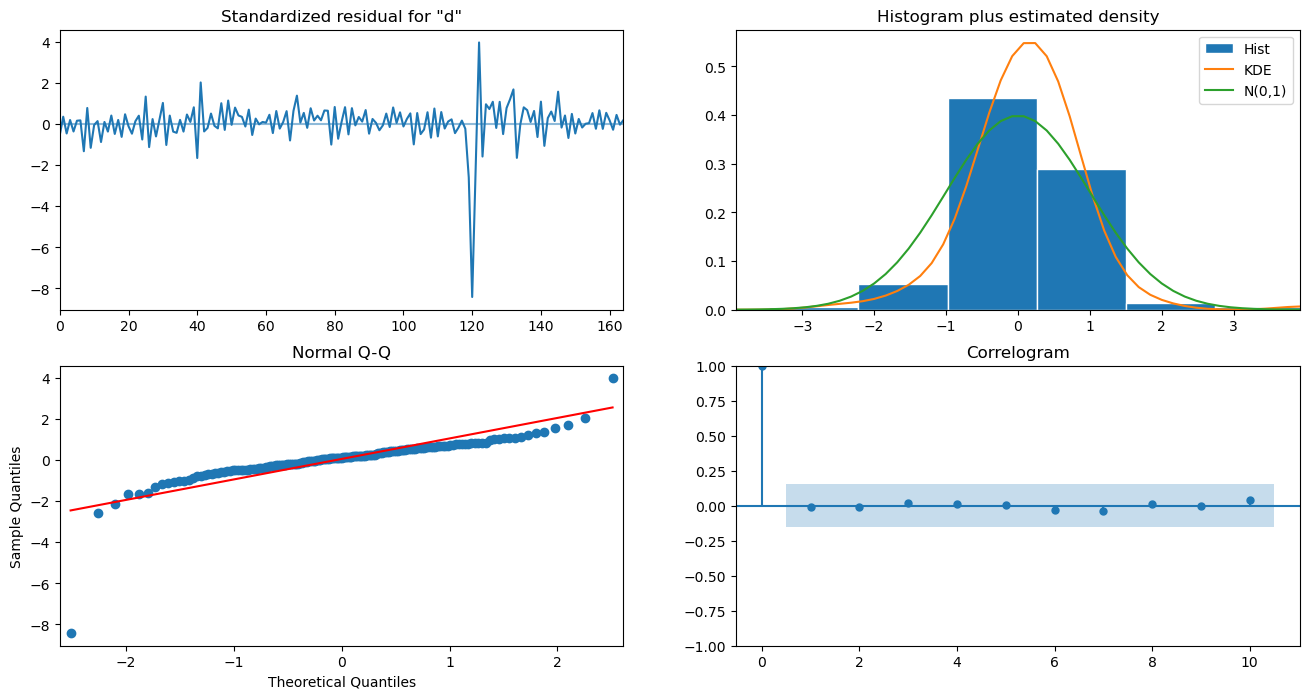

In [38]:
sarima_results.plot_diagnostics(figsize=(16, 8))
plt.show()

In [39]:
results = sarima_results.forecast(steps=12)

In [40]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error, r2_score
#Evaluation  metric 

mae = mean_absolute_error(test, results)
rmse = np.sqrt(mean_squared_error(test, results))
mape = np.mean(np.abs((test - results) / test)) * 100
r2 = r2_score(test, results)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2 : {r2:.2f}")

MAE  : 0.061
RMSE : 0.079
MAPE : nan%
R2 : 0.14
